In [1]:
!pip install --upgrade --no-cache-dir "sagemaker<3" pandas numpy matplotlib seaborn scikit-learn "torch==2.6" torchvision sagemaker boto3

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.


In [3]:
import sagemaker

sess = sagemaker.Session()
bucket = sess.default_bucket()
prefix = "sagemaker"

import boto3
import re
from sagemaker import get_execution_role

role = get_execution_role()

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import struct
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from PIL import Image
from sagemaker.inputs import TrainingInput
from sagemaker.s3 import S3Uploader

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [11]:
class CustomDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.FloatTensor(self.images[idx])

        if self.transform:
            img = self.transform(img)

        if self.labels is not None:
            return img, int(self.labels[idx])
        return img

In [12]:
with open('./dataset/train-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    images = np.fromfile(f, dtype=np.uint8).reshape(n, 1, rows, cols)

with open('./dataset/train-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    labels = np.fromfile(f, dtype=np.uint8)

with open('./dataset/t10k-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    test_images = np.fromfile(f, dtype=np.uint8).reshape(n, 1, rows, cols)

with open('./dataset/t10k-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    test_labels = np.fromfile(f, dtype=np.uint8)

images      = images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

train_dataset = CustomDataset(images, labels)
test_dataset  = CustomDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64)

In [5]:
%%bash

curl -L -o ./mnist.zip https://www.kaggle.com/api/v1/datasets/download/hojjatk/mnist-dataset

mkdir mnist
unzip -q mnist.zip -d ./mnist

mkdir dataset
mv mnist/* dataset/

rm mnist.zip
zip -rq mnist.zip dataset/

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0   0     0   0     0     0     0  --:--:-- --:--:-- --:--:--     0
100 22570k 100 22570k   0     0 51011k     0  --:--:-- --:--:-- --:--:-- 51011k


In [6]:
inputs = S3Uploader.upload("mnist.zip", "s3://{}/{}".format(bucket, prefix))

In [15]:
from sagemaker.pytorch import PyTorch

estimator = PyTorch(
    entry_point="train.py",
    framework_version="2.6",
    py_version="py312",
    instance_type="ml.g4dn.xlarge",
    instance_count=1,
    output_path="s3://{}/{}/output/".format(bucket, prefix),
    checkpoint_s3_uri="s3://{}/{}/checkpoint/".format(bucket, prefix),
    role=role
)

estimator.fit({
    "train": TrainingInput("s3://{}/{}/mnist.zip".format(bucket, prefix)),  # /opt/ml/input/data/train
})

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker:Creating training-job with name: pytorch-training-2026-06-18-00-00-54-165


2026-06-18 00:00:54 Starting - Starting the training job......
2026-06-18 00:01:55 Downloading - Downloading input data......
2026-06-18 00:02:31 Downloading - Downloading the training image.....................
2026-06-18 00:06:28 Training - Training image download completed. Training in progress...bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
CUDA compat package should be installed for NVIDIA driver smaller than 560.35.05
Current installed NVIDIA driver version is 570.211.01
Skipping CUDA compat setup as newer NVIDIA driver is installed
2026-06-18 00:06:44,038 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2026-06-18 00:06:44,059 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2026-06-18 00:06:44,070 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2026-06-18 00:06:44,073 sagemaker_pytorch_contai

In [16]:
predictor = estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.g4dn.xlarge",
)

INFO:sagemaker:Repacking model artifact (s3://sagemaker-us-east-1-200148130345/sagemaker/output/pytorch-training-2026-06-18-00-00-54-165/output/model.tar.gz), script artifact (s3://sagemaker-us-east-1-200148130345/pytorch-training-2026-06-18-00-00-54-165/source/sourcedir.tar.gz), and dependencies ([]) into single tar.gz file located at s3://sagemaker-us-east-1-200148130345/pytorch-training-2026-06-18-00-12-22-676/model.tar.gz. This may take some time depending on model size...
INFO:sagemaker:Creating model with name: pytorch-training-2026-06-18-00-12-22-676
INFO:sagemaker:Creating endpoint-config with name pytorch-training-2026-06-18-00-12-22-676
INFO:sagemaker:Creating endpoint with name pytorch-training-2026-06-18-00-12-22-676


----------!

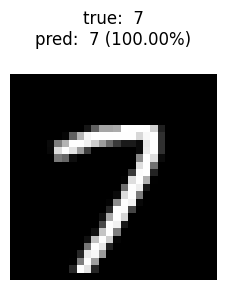

In [39]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

idx = torch.randint(len(test_dataset), (1,)).item()
sample_image, sample_label = test_dataset[idx]

output = predictor.predict(
    np.expand_dims(sample_image, 0).astype(np.float32)
)
output_tensor = torch.from_numpy(np.array(output))
probs = F.softmax(output_tensor, dim=1)
confidence, predicted = torch.max(probs, 1)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image.squeeze().numpy(), cmap='gray')
plt.axis('off')
plt.title(
    f"true:  {classes[sample_label]}\n"
    f"pred:  {classes[predicted.item()]} ({confidence.item()*100:.2f}%)\n"
)
plt.tight_layout()
plt.show()